# 행동 벤치마크 v1 — "시뮬레이터가 사람답게 구는가"

**이게 뭐냐면**: 시뮬레이터의 **상식 회귀 테스트**예요. 일부러 만든 가상 정책 5개(일부는 농담조)를 넣고,
시민들이 **상식 방향으로 갈라지는지**를 봅니다 — 직장인은 환영하는데 은퇴자는 시큰둥한가? 어르신 혜택을 깎으면 어르신이 화내는가?

**왜 벤치마크냐면**: 한 번 쓰고 버리는 검증이 아니라, **모델이나 프롬프트를 바꿀 때마다 다시 돌려서**
"여전히 사람답게 구는가"를 확인하는 고정 시험지이기 때문이에요. 기대 방향은 실행 *전에* 등록했습니다(`eval/behavior_bench_v1.md`).

| 시나리오 | 갈등 축 | 톤 | 묻는 것 |
|---|---|---|---|
| 주 3.5일 근무제 | 직업 | 😄 | 이해관계 따라 갈리나 |
| 전 국민 반려묘 보급 | 순효용 | 😄 | 공짜로 포장된 '살아있는 책임'을 간파하나 |
| 경로 무임승차 폐지 | 세대 | 진지 | 혜택 깎인 집단이 반발·행동하나 |
| 성별 균형 기여금 (남 +10만/여 −10만) | 성별 | 부조리 | 갈등이 올바른 축으로 갈라지나 + **남성 반응 리트머스** |
| 고소득자 의무 나눔제 | 소득 | 진지 | 자기 형편을 스스로 판정해 반응하나 |

*보너스: 이 5개는 데모 모드 녹화본이기도 해서, 앱에서 키 없이 그대로 재생할 수 있어요(발표 시연 가능).*

In [1]:
# 준비 — 채점 결과 로드 (LLM 0콜)
import json, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / 'eval').exists():
    ROOT = ROOT.parent
B = json.loads((ROOT / 'eval' / 'behavior_bench_results.json').read_text(encoding='utf-8'))
SC = B['scenarios']
print('모델:', B['model'], '/ 체크:', B['n_checks'], '개')

C_SUP, C_OPP, C_MIX = '#2a6fdb', '#d9534f', '#b8b8b8'

def group_chart(key, title_note=''):
    """집단별 찬/반/혼합 비교 — 패널 1개 = 비교 1개."""
    s = SC[key]
    groups = s.get('by_group') or {'전체': s['overall']}
    fig, ax = plt.subplots(figsize=(8.8, 4.2))
    labels = list(groups)
    x = range(len(labels))
    w = 0.26
    for off, fld, col, lab in ((-w, 'support', C_SUP, '찬성'), (0, 'oppose', C_OPP, '반대'), (w, 'mixed', C_MIX, '혼합·글쎄')):
        vals = [groups[g][fld] or 0 for g in labels]
        ax.bar([i + off for i in x], vals, w, color=col, label=lab)
        for i, v in zip(x, vals):
            if v >= 4: ax.text(i + off, v + 1.5, f'{v:.0f}', ha='center', fontsize=9)
    ax.set_xticks(list(x))
    ax.set_xticklabels([f'{g} (n={groups[g]["n"]})' for g in labels], fontsize=11)
    ax.set_ylim(0, 112); ax.set_ylabel('비율 (%)')
    ax.set_title(f'{key} — 집단별 입장 {title_note}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.25)
    plt.show()
    print(f"사회혼란도(불만 평균) {s.get('unrest')} · 집단행동 신호 {s.get('action_signal_pct')}% · 속내 분포 {s.get('behavior')}")

def quotes(key, limit=4):
    for q in SC[key].get('quotes', [])[:limit]:
        print(f"🗣 {q['name']}({q['age']}, {q['occupation'][:10]}) [{q['why']}]")
        print(f"   \"{q['text']}\"")
        if q.get('behavior_text'):
            print(f"   🌙 속내({q.get('behavior_class')}): {q['behavior_text']}")
        print()

모델: gemini:gemini-3-flash-preview / 체크: 7 개


In [2]:
# 스코어카드 — 기대 방향은 녹화 전에 등록됨
df = pd.DataFrame([{'#': c['id'], '시나리오': c['scenario'], '체크(사전등록)': c['name'],
                    '측정값': c['measured'], '판정': '통과' if c['pass'] else 'FAIL'}
                   for c in B['checks']])
display(df.style.map(lambda v: 'color:#b03030;font-weight:bold' if v == 'FAIL' else 'color:#1a7a3a', subset=['판정']))
print(f"종합: {B['n_pass']}/{B['n_checks']} -> {'통과' if B['overall_pass'] else '미달'} (기준 6+)")

,#,시나리오,체크(사전등록),측정값,판정
0,B1,주 3.5일 근무제,취업자 찬성률 > 무직·은퇴 찬성률,취업자 16.7% vs 무직·은퇴 9.1%,통과
1,B2,전 국민 반려묘 보급,찬성률 <= 50% (무지성 찬성 아님),찬성 4.2%,통과
2,B3-a,경로 무임승차 폐지,60세+ 반대율 > 60세 미만 반대율,60+ 57.1% vs 미만 5.9%,통과
3,B3-b,경로 무임승차 폐지,60세+ 강한 불만 비율 > 60세 미만,60+ 71.4% vs 미만 41.2%,통과
4,B4-a,성별 균형 기여금,여성 반대율 >= 70% (거의 전원),여성 반대 100.0%,통과
5,B4-b,성별 균형 기여금,여성 반대율 > 남성 반대율,여 100.0% vs 남 23.1%,통과
6,B5,고소득자 의무 나눔제,자가판정 대상자 불만 평균 > 비대상자,대상(2명) 100 vs 비대상(22명) 62.3,통과


종합: 7/7 -> 통과 (기준 6+)


---
## B1. 주 3.5일 근무제 😄 — 이해관계 따라 갈리나

수요일 오후부터 전국이 쉬는 반쪽 근무제. **직장인에겐 꿀, 무직·은퇴자에겐 남 얘기**여야 상식입니다.

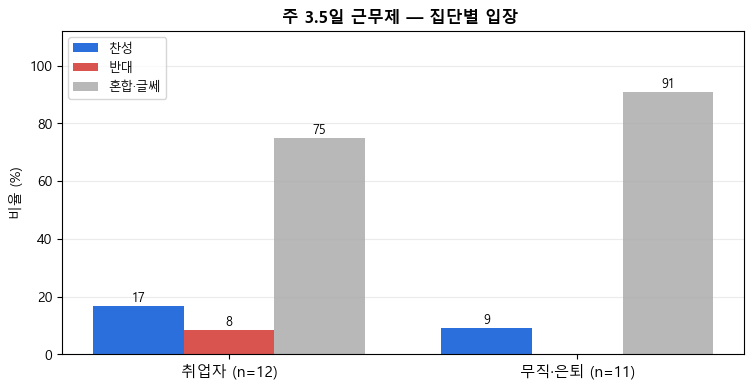

사회혼란도(불만 평균) 57.1 · 집단행동 신호 8.3% · 속내 분포 {'inaction': 13, 'comply': 9, 'complain': 2}
🗣 김은서(26, 주방 보조원) [취업자 환영]
   "와, 진짜 수요일 오후부터 쉬면 대박이겠다. 월급 조금 깎이는 건 아쉽지만 그래도 시간 생기는 게 어디야. 그 시간에 브런치 카페 메뉴도 더 연구하고 인테리어 소품도 보러 다닐 수 있으니까 나는 완전 찬성이야."
   🌙 속내(comply): 근무 시간이 줄어든 만큼 그 시간을 그냥 허비하지 않고 카페 창업을 위한 레시피 개발이랑 플레이팅 연습에 꼬박꼬박 투자할 생각이다.

🗣 이준영(41, 자동차공학 기술자 ) [임금·실현 의심]
   "쉬는 건 좋죠. 그런데 우리 연구소 프로젝트 일정이 엑셀로 아주 정밀하게 짜여 있거든요. 주 28시간으로 줄어들면 업무 프로세스를 아예 새로 설계해야 할 텐데, 마감 기한 맞추면서 데이터 검증까지 완벽하게 하려면 시간이 좀 빠듯하긴 하겠어요. 임금 90%면 10% 깎이는 건데, 우리 집 가계부도 다시 한번 계산기 두드려봐야 할 것 같고요. 그래도 수요일 오후에 쉴 수 있으면 가족들이랑 대청호"
   🌙 속내(comply): 줄어든 근무 시간 안에도 기존 성과를 낼 수 있도록 팀원들의 업무 효율을 소수점 단위까지 관리하는 정밀한 프로세스를 구축해서, 오히려 내가 팀장 적임자라는 걸 보여줄 생각이다.



In [3]:
group_chart('주 3.5일 근무제')
quotes('주 3.5일 근무제')

---
## B2. 전 국민 반려묘 보급 😄 — 공짜 함정을 간파하나

고양이는 현금이 아니라 **살아있는 책임**입니다(사료비·병원비·임대 규약·알레르기).
"공짜니까 찬성"으로 쏠리지 않아야 상식 — 그리고 찬성한 소수가 **원래 동물을 좋아하는 사람**이라면, 입장이 인구통계가 아니라 서사 깊은 곳과 정렬된다는 보너스 증거예요.

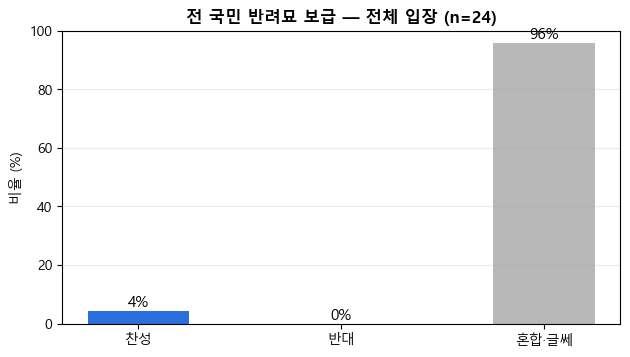

사회혼란도 32.9 · 집단행동 신호 0.0% · 속내 분포 {'inaction': 20, 'comply': 2, 'workaround': 1, 'exploit': 1}
찬성자 1명 중 페르소나 서사에 동물 친화 단서 보유: 1명 — ['신민재']

🗣 신민재(24, 사무 보조원) [찬성자]
   "와, 이거 진짜 대박인데? 안 그래도 나 나중에 펫 푸드 브랜드 만들 생각이라 고양이 한 번 키워보고 싶었거든. 유기묘들 입양 보내는 거니까 취지도 좋고, 처음에 사료비까지 준다니까 완전 개이득이지. 부모님만 잘 설득하면 우리 집 거실에 고양이 한 마리 돌아다니는 건데, 생각만 해도 귀엽다."
   🌙 속내(comply): 정책 지원 받아서 고양이 키우면서 내가 직접 만든 수제 사료나 간식 테스트해 보는 용도로 활용해봐야겠다. 부모님은 평소처럼 넉살 좋게 넘어가면 허락해주시겠지.

🗣 김은서(26, 주방 보조원) [부담·책임 인식]
   "고양이는 귀엽긴 한데, 털 날리는 거랑 가구 긁는 거 생각하면 좀 고민되네. 나중에 내 카페 차릴 생각도 있어서 위생도 신경 쓰이고... 그래도 나라에서 용품도 주고 사료값도 보태준다니까 관심은 가는데, 우리 집 인테리어 망가질까 봐 일단 남편이랑 얘기는 해봐야겠다."
   🌙 속내(inaction): 고양이는 예쁘지만 내 소중한 가구랑 소품이 망가지는 건 싫어서, 실제 신청하기보다는 남들이 키우는 거 구경이나 할 것 같다.

🗣 서현빈(21, 육군 병사) [일탈(workaround)]
   "고양이 키우면 정서적으로 안정되고 좋을 것 같긴 한데, 제가 지금 군 복무 중이라 직접 챙기기가 좀 어렵네요. 그래도 사료비랑 키트 지원해준다고 하니까 휴가 나갔을 때 생각하면 솔깃해요. 부모님 설득해서 제 이름으로 미리 신청해두고 집에서 키우게 할까 고민됩니다."
   🌙 속내(workaround): 군인 신분이라 직접 양육은 못 하지만, 일단 제 명의로 혜택을 다 받아두고 실질적인 관리는 부모님께 맡기는 식으로 신청할 생각입니다.

🗣 

In [4]:
s = SC['전 국민 반려묘 보급']
ov = s['overall']
fig, ax = plt.subplots(figsize=(7.2, 3.8))
vals = [ov['support'], ov['oppose'], ov['mixed']]
ax.bar(['찬성', '반대', '혼합·글쎄'], vals, 0.5, color=[C_SUP, C_OPP, C_MIX])
for i, v in enumerate(vals):
    ax.text(i, v + 1.5, f'{v:.0f}%', ha='center', fontsize=11)
ax.set_ylim(0, 100); ax.set_ylabel('비율 (%)')
ax.set_title(f'전 국민 반려묘 보급 — 전체 입장 (n={ov["n"]})', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.25)
plt.show()
print(f"사회혼란도 {s['unrest']} · 집단행동 신호 {s['action_signal_pct']}% · 속내 분포 {s['behavior']}")
align = s.get('supporter_animal_alignment') or []
if align:
    hit = sum(1 for a in align if a['animal_hint'])
    print(f"찬성자 {len(align)}명 중 페르소나 서사에 동물 친화 단서 보유: {hit}명 — {[a['name'] for a in align if a['animal_hint']]}")
else:
    print('찬성자 0명')
print()
quotes('전 국민 반려묘 보급')

---
## B3. 경로 무임승차 폐지 — 혜택 깎인 세대가 반발·행동하나

어르신 혜택을 직접 깎는 정책. **60세 이상이 더 반대하고, 더 강하게 불만이고, 민원·항의 같은 집단행동 신호**가 나와야 상식입니다. (주의: 60세+ 집단은 7명이라 1명 = ~14%p의 거친 해상도)

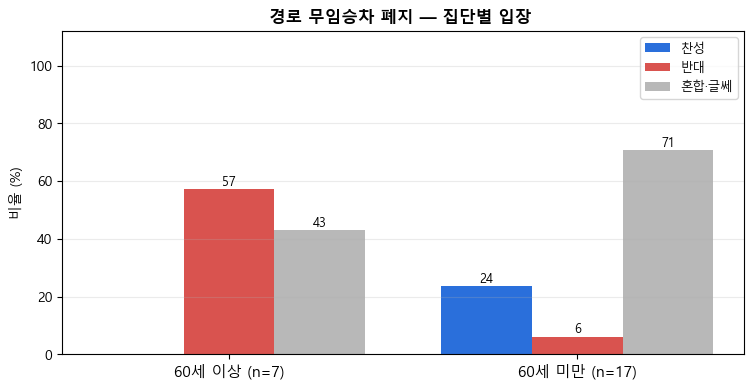

사회혼란도(불만 평균) 46.2 · 집단행동 신호 8.3% · 속내 분포 {'inaction': 17, 'comply': 3, 'complain': 2, 'exploit': 1, 'workaround': 1}
강한 불만(꽤+매우) 비율: 60세 이상 71.4% vs 60세 미만 41.2%

🗣 정명숙(60, 무직) [고령 반발]
   "아이고, 세상에. 나도 이제 몇 년만 있으면 공짜로 지하철 탈 수 있겠다 캤는데 그걸 딱 없앤다 카네. 적자가 많다 카는 뉴스야 봤지만도, 노인네들 그거 타고 바람 쐬러 다니는 게 얼마나 큰 낙인데... 바우처 1만 5천 원 준다 캐도 요새 물가에 그게 돈이가? 우리처럼 형편 빠듯한 집구석은 나중에 65세 돼서 바우처라도 못 받으면 어짤까 싶어 걱정시럽네."
   🌙 속내(comply): 당장은 내가 65세가 아이라가 할 수 있는 게 없지만도, 나중에 나이 차면 주민센터 가서 바우처 신청할 수 있는지 꼼꼼하게 물어보고 챙길 생각이다.

🗣 장원주(66, 일반 간호사) [집단행동 신호]
   "허참, 이게 말이 되는 소린가요? 평생 성실하게 일하고 이제 좀 쉬면서 산에도 가고 여기저기 다녀보려니까 무임승차를 없앤다니요. 1만 5천 원 준다는 것도 우스운 일이지요. 그거 지하철 몇 번 타면 끝인데, 그거 받으러 서류 떼고 주민센터 오라는 게 사람 골탕 먹이는 거지 뭡니까. 나라에서 어르신들 대우를 이렇게밖에 못 하나 싶어서 참 씁쓸하네요."
   🌙 속내(complain): 가만히 있으면 그냥 뺏기는 거지요. 기원 분들이나 주변 사람들하고 뜻을 모아서 주민센터에 단체로 민원을 넣거나 항의라도 하러 가야겠습니다.

🗣 김은서(26, 주방 보조원) [젊은층 시선]
   "여기는 지하철도 없는데 뭐... 나랑은 먼 나라 이야기 같아요. 나중에 나이 들어서 혜택 못 받으면 아쉽겠지만 지금 당장은 별 생각 없네요."
   🌙 속내(inaction): 진짜 나랑은 상관없는 일이라 그냥 그런가 보다 해요. 나중에 내 카페 차릴 준비나 더 하는 

In [5]:
group_chart('경로 무임승차 폐지')
sd = SC['경로 무임승차 폐지'].get('strong_dissat', {})
print(f"강한 불만(꽤+매우) 비율: 60세 이상 {sd.get('60세 이상')}% vs 60세 미만 {sd.get('60세 미만')}%")
print()
quotes('경로 무임승차 폐지')

---
## B4. 성별 균형 기여금 (남 +10만 / 여 −10만) — 부조리 갈등 + 리트머스

일부러 만든 노골적 부조리 정책. **여성은 거의 전원 반대**해야 상식이고(이게 채점 대상),
**남성의 반응은 채점하지 않고 관찰만** 합니다 — 순수 이해관계로 움직이면 남성은 찬성으로 쏠릴 거고,
공정성 감각이 작동하면 이득인데도 반대할 거예요. 어느 쪽이든 시뮬레이터의 성격을 알려주는 리트머스 시험지.

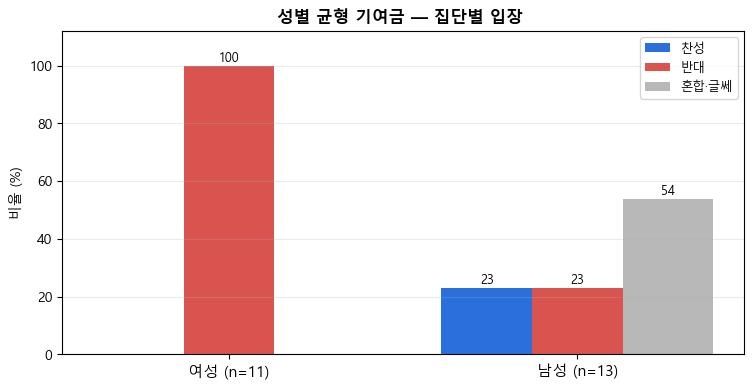

사회혼란도(불만 평균) 80.8 · 집단행동 신호 41.7% · 속내 분포 {'complain': 11, 'comply': 7, 'inaction': 6}
혼란도(불만 평균): 여성 100 vs 남성 64.6
리트머스 관찰 — 남성 분포: 찬성 23.1% / 반대 23.1% / 혼합 53.8%

🗣 김은서(26, 주방 보조원) [여성 반발]
   "아니, 이게 무슨 말도 안 되는 소리야? 내가 힘들게 주방에서 식재료 썰어서 번 돈을 왜 뺏어가요? 남편은 10만 원 받고 나는 10만 원 내면 결국 우리 집 돈은 똑같은 거 아니냐고 할 수도 있는데, 그건 아니지. 내 통장에서 찍히는 숫자가 줄어드는 건데 기분 진짜 별로예요. 예천 와서 적응하느라 나도 나름 고생하는데 무슨 성별 균형이라는 건지 이해가 안 가네."
   🌙 속내(complain): 남편 통장에 들어오는 10만 원은 무조건 내 카페 창업 저금통장에 넣으라고 못 박아야겠어. 내 이름으로 나가는 돈이니까 그 정도는 당연히 내가 챙겨야지.

🗣 이준영(41, 자동차공학 기술자 ) [남성의 규범적 반대]
   "이게 도대체 어떤 데이터에 근거해서 나온 계산법인지 모르겠네요. 내가 10만 원 받고 와이프가 10만 원 내면 우리 집은 0원인데, 행정적으로 자원을 낭비하는 꼴 아닌가요? 성별로만 구분 짓는 건 너무 단순하고 비논리적인 설계라 연구원 입장에서 봐도 납득이 안 됩니다."
   🌙 속내(complain): 정책의 설계 근거와 예상되는 사회적 비용에 대한 데이터를 확인하고 싶다. 논리적으로 맞지 않는 부분에 대해 국민신문고에 정식으로 이의 신청을 제기할 생각이다.

🗣 신민재(24, 사무 보조원) [남성의 이득 수용]
   "와, 진짜 대박. 이거 나 10만 원 받는다는 거잖아? 개이득이지. 근데 여자애들 10만 원 떼가는 건 좀 선 넘은 거 아닌가 싶긴 한데... 어쨌든 나야 주는 거니까 거절할 이유는 없지. 형들이랑 술 마실 때 안주 하나 더 시켜도 되겠네."
   🌙 속내(comply): 나라에서 

In [6]:
group_chart('성별 균형 기여금')
ug = SC['성별 균형 기여금'].get('unrest_by_group', {})
print(f"혼란도(불만 평균): 여성 {ug.get('여성')} vs 남성 {ug.get('남성')}")
mal = SC['성별 균형 기여금']['by_group']['남성']
print(f"리트머스 관찰 — 남성 분포: 찬성 {mal['support']}% / 반대 {mal['oppose']}% / 혼합 {mal['mixed']}%")
print()
quotes('성별 균형 기여금')

---
## B5. 고소득자 의무 나눔제 — 자기 형편을 스스로 판정하나

"평균의 150% 초과 소득자는 월 30만 원 의무 기부". 우리 코드는 누가 고소득인지 거칠게만 아는데(휴리스틱 high 2명),
시민들은 **자기 페르소나의 형편을 읽고 스스로 '나는 대상이다/아니다'를 판정**합니다. 그 자가판정 대상자가 더 불만이어야 상식.
보너스 관찰: "의무 기부면 그게 기부냐 세금이지" 같은 **모순 지적**이 나오는가.

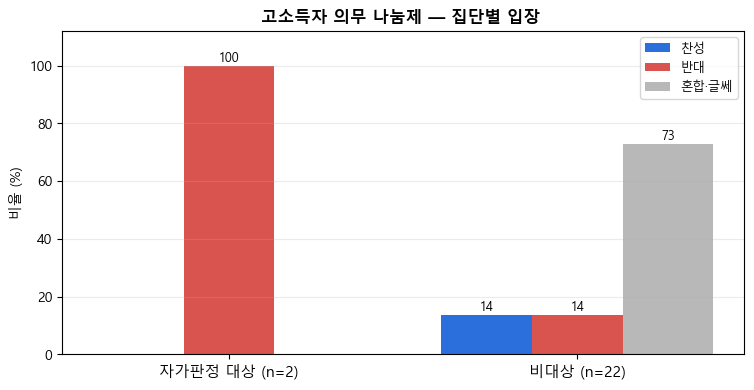

사회혼란도(불만 평균) 65.4 · 집단행동 신호 8.3% · 속내 분포 {'inaction': 20, 'workaround': 2, 'comply': 1, 'complain': 1}
자가판정 대상자: 2명 (코드 휴리스틱 high=2명과 대조) · 불만 평균: 대상 100 vs 비대상 62.3 · '강제 기부 모순' 지적 8건

🗣 이준영(41, 자동차공학 기술자 ) [자가판정 대상자]
   "나눔이라는 건 자발적으로 마음이 동해서 할 때 의미가 있는 거지, 이걸 아예 법으로 정해서 매달 30만 원씩 떼어가겠다는 건 그냥 이름만 바꾼 세금 아닙니까? 심지어 기부금 공제도 안 해준다니, 열심히 일해서 소득 높인 사람만 역차별하는 거죠. 이건 계산기 두드려볼 것도 없이 아주 불합리한 정책입니다."
   🌙 속내(workaround): 소득을 150% 이하로 맞출 수 있는 방법이 있는지 꼼꼼하게 시뮬레이션해봐야겠어. 수당을 다른 방식으로 받거나 비과세 항목을 늘려서라도 이 대상에서 빠져나갈 구멍을 찾을 거야.

🗣 신민재(24, 사무 보조원) ['강제 기부 모순' 지적]
   "와, 이거 거의 세금 아닌가요? 나중에 돈 많이 벌면 기부야 할 수 있는데, 아예 딱 정해서 강제로 내라고 하면 좀... 게다가 연말정산 공제도 안 된다면서요? 전 아직 월급이 귀여운 수준이라 상관없긴 한데, 나중에 창업해서 대박 나면 이것부터 걱정해야겠는데요."
   🌙 속내(inaction): 지금은 내가 낼 돈이 없어서 상관없지만, 나중에 돈 많이 벌었을 때 생돈 나가는 기분 들 것 같아서 싫다. 부모님 소득이 대상인지나 슬쩍 확인해 봐야지.

🗣 신선옥(60, 무직) [비대상의 시선]
   "아이고, 돈 많은 사람들이야 한 달에 30만 원 내는 게 큰일이겠나 싶다가도, 억지로 내라 카면 마음이 좀 그렇긴 하겠다. 그래도 그 돈으로 우리 같은 사람 사는 데 보태고 복지관 같은 데 잘 쓰인다 카면 참 좋은 일인 거 같네. 세상이 워낙 팍팍하니 이런 법도 생기는 모양이라."
   🌙 속내

In [7]:
group_chart('고소득자 의무 나눔제')
s5 = SC['고소득자 의무 나눔제']
print(f"자가판정 대상자: {s5['n_self_target']}명 (코드 휴리스틱 high=2명과 대조) · "
      f"불만 평균: 대상 {s5['unrest_target']} vs 비대상 {s5['unrest_nontarget']} · "
      f"'강제 기부 모순' 지적 {s5['paradox_mentions']}건")
print()
quotes('고소득자 의무 나눔제')

---
## 한계 (정직)

- **1회 실행** (폭 우선 설계) — 회차 노이즈 참고치는 검증 ②의 실측(회차 간 std ~3점). 비율 최소 단위 ~4.2%p.
- 집단이 작은 축(60세+ 7명, 자가판정 대상 소수)은 해상도가 거칢.
- 가상 정책이라 **현실 정답과의 비교가 아님** — "상식 방향으로 갈라지는가"까지만 묻는다.
- 시나리오·기대는 사용자와 합의해 녹화 전 등록(`eval/behavior_bench_v1.md`). 반려묘는 사용자 앱 파일럿을 먼저 봤음(사전 지식 공개).

## 벤치마크로 쓰는 법

모델·프롬프트 등 측정도구를 바꾸면: `python _record_demo.py --only "<정책명>"` ×5 재녹화 → `python _run_behavior_bench.py` 재채점 → 스코어카드를 이 판과 비교.
데모 녹화본을 겸하므로 재녹화하면 앱 데모도 같이 갱신된다.

*이 노트북 재실행: `python -m nbconvert --to notebook --execute --inplace notebooks/행동벤치_v1.ipynb` (LLM 0콜)*